This notebook fits by-cre models on the takshesi's data 

# Setup

In [1]:
#imports
import pandas as pd
import numpy as np
import time
import pickle
from formulaic import Formula
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

from tensorzinb.tensorzinb import TensorZINB
import scMPRAforge as scm

2025-09-17 13:50:36.002658: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-17 13:50:36.009616: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /vast/palmer/apps/avx2/software/code-server/4.91.1/lib:/vast/palmer/apps/avx2/software/gettext/0.22.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/libiconv/1.17-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/ncurses/6.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/libxml2/2.12.7-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/XZ/5.4.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/expat/2.6.2-GCCcore-13.3.0/lib:/vast/palmer/apps/av

In [8]:
#create dask cluster

from dask_jobqueue import SLURMCluster
from dask.distributed import Client

cluster=SLURMCluster(
    cores=4,#cores per slurm job
    memory="128G",#memory per slurm job
    #memory="32G",#memory per slurm job
    processes=1,#dask workers per slurm job
    job_extra_directives=["-p ycga", 
        f"--job-name=takeshi_scp1",
        f"--time=1:00:00",
        f"--output=takeshi_scp1_%j.out"]
)

# cluster=SLURMCluster(
#         cores=4,#cores per slurm job
#         memory="64G",#memory per slurm job
#         processes=1,#dask workers per slurm job
#         job_extra_directives=["-p gpu", 
#             "--gpus=a100",
#             "--job-name=scmpra_gpu",
#             f"--time=1:00:00",
#             f"--output=takeshi_gpu_%j.out"]
#     )


cluster.scale(jobs=4)

client = Client(cluster,
        timeout=f"{5*60}s",   # Client <-> scheduler timeout 
        heartbeat_interval="20s"  # Worker heartbeat interval
    )

# from dask.distributed import Client, LocalCluster
# cluster=LocalCluster(memory_limit='16GB', n_workers=8)
# client = Client(cluster)

# #create dask cluster
# from dask.distributed import Client, LocalCluster
# cluster=LocalCluster(n_workers=10)
# client = Client(cluster)

In [7]:
cluster.close()

In [3]:
path="/gpfs/gibbs/pi/reilly/tabula_data/takeshi"
name_minp="takeshi_minp"
name_scp1 ="takeshi_scp1"
#  name="takeshi_gpu"
data_root="/gpfs/gibbs/pi/reilly/tabula_data"

# Filter and format raw data

In [6]:
scp1 = pd.read_table('%s/all.integrate.scp1.xls' % path)
scp1_save = scp1.copy()

scp1["mBC_count"] = scp1["mBC_count"].fillna(0)
scp1["mBC_umi_pcr"] = scp1["mBC_umi_pcr"].fillna(0)
scp1 = scp1[scp1["oBC_count"] > 5] 
new_cols = {
    'oBC':'transfection_bc',
    'CELL':'cell_bc',
    'oBC_count':'umis_transfection_bc',
    'umi_pcr':'reads_transfection_bc',
    'CRE_name':'cre_id',
   # 'nCount_RNA':'',
   # '':'reads_DNA',
    'Celltype':'cell_type',
    'mBC':'mpra_bc',
    'mBC_count':'umis_mpra_bc',
    'mBC_umi_pcr':'reads_mpra_bc',
}
scp1 = scp1.rename(columns=new_cols)
scp1['rep_id'] = 1

cell_types = {
    0 : 'IFN',
    1 : 'Proliferating',
    2: 'Stress_responsive',
}

scp1['cell_type'] = scp1['cell_type'].replace(cell_types)


In [7]:
minp = pd.read_table('%s/all.integrate.minp.xls' % path)
minp_save = minp.copy()

minp["mBC_count"] = minp["mBC_count"].fillna(0)
minp["mBC_umi_pcr"] = minp["mBC_umi_pcr"].fillna(0)
minp = minp[minp["oBC_count"] > 5] 
new_cols = {
    'oBC':'transfection_bc',
    'CELL':'cell_bc',
    'oBC_count':'umis_transfection_bc',
    'umi_pcr':'reads_transfection_bc',
    'CRE_name':'cre_id',
   # 'nCount_RNA':'',
   # '':'reads_DNA',
    'Celltype':'cell_type',
    'mBC':'mpra_bc',
    'mBC_count':'umis_mpra_bc',
    'mBC_umi_pcr':'reads_mpra_bc',
}
minp = minp.rename(columns=new_cols)
minp['rep_id'] = 1

cell_types = {
    0 : 'IFN',
    1 : 'Proliferating',
    2: 'Stress_responsive',
}

minp['cell_type'] = minp['cell_type'].replace(cell_types)


In [8]:
minp

,transfection_bc,cell_bc,umis_transfection_bc,reads_transfection_bc,error_uncorrected_umi_count,cre_id,error_corrected_oBC,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,RNA_snn_res.0.1,seurat_clusters,scDblFinder.class,cell_type,CELL_nomismatch,mpra_bc,umis_mpra_bc,reads_mpra_bc,rep_id
1,AAAAAAAAAAGCATTT,AAGGTCAGTTGCCTTC,8,13,8,chr3:59868192:NA:NA:R:nc,AAAAAAAAAAGCATTT,pbmc3k,3791,1786,4.220522,1,1,singlet,Proliferating,AAGGTCAGTTGCCTTC,TTGAGCATGATAACCGGTGG,0.0,0.0,1
4,AAAAAAAAAAGCATTT,AGCTGAGAGTCGAGTC,12,13,12,chr3:59868192:NA:NA:R:nc,AAAAAAAAAAGCATTT,pbmc3k,3357,1750,1.727733,2,2,singlet,Stress_responsive,AGCTGAGAGTCGAGTC,TTGAGCATGATAACCGGTGG,0.0,0.0,1
6,AAAAAAAAAAGCATTT,ATAGGCTCAATCTACT,19,27,19,chr3:59868192:NA:NA:R:nc,AAAAAAAAAAGCATTT,pbmc3k,1266,870,4.344392,0,0,singlet,IFN,ATAGGCTCAATCTACT,TTGAGCATGATAACCGGTGG,0.0,0.0,1
9,AAAAAAAAAAGCATTT,CAACGATCACATAGAC,18,24,18,chr3:59868192:NA:NA:R:nc,AAAAAAAAAAGCATTT,pbmc3k,3480,1857,4.885057,0,0,singlet,IFN,CAACGATCACATAGAC,TTGAGCATGATAACCGGTGG,0.0,0.0,1
10,AAAAAAAAAAGCATTT,CGATGGTTCGATGCAC,8,10,8,chr3:59868192:NA:NA:R:nc,AAAAAAAAAAGCATTT,pbmc3k,8271,3037,5.017531,1,1,singlet,Proliferating,CGATGGTTCGATGCAC,TTGAGCATGATAACCGGTGG,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12369969,TTTTCAAAAATAAGGA,GTCATCCCAAGGGATA,6,9,6,chr1:37911349:G:A:A:trynka,TTTTCAAAAATAAGGA,pbmc3k,3500,1552,7.400000,2,2,singlet,Stress_responsive,GTCATCCCAAGGGATA,ATTTTCTTGCTGTATATCCA,0.0,0.0,1
12369970,TTTTCAAAAATAAGGA,TCTGGGTAGCGGTCTG,8,12,8,chr1:37911349:G:A:A:trynka,TTTTCAAAAATAAGGA,pbmc3k,2135,1227,7.587822,0,0,singlet,IFN,TCTGGGTAGCGGTCTG,ATTTTCTTGCTGTATATCCA,0.0,0.0,1
12369971,TTTTCAAAAATAAGGA,TGAGTCGCAACATAGC,8,9,8,chr1:37911349:G:A:A:trynka,TTTTCAAAAATAAGGA,pbmc3k,1312,863,2.515244,0,0,singlet,IFN,TGAGTCGCAACATAGC,ATTTTCTTGCTGTATATCCA,0.0,0.0,1
12369972,TTTTCAAAAATAAGGA,TGATCCGGTTTCACGG,6,9,6,chr1:37911349:G:A:A:trynka,TTTTCAAAAATAAGGA,pbmc3k,2639,1194,5.456612,0,0,singlet,IFN,TGATCCGGTTTCACGG,ATTTTCTTGCTGTATATCCA,0.0,0.0,1


In [9]:
scp1

,transfection_bc,cell_bc,umis_transfection_bc,reads_transfection_bc,error_uncorrected_umi_count,cre_id,error_corrected_oBC,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,RNA_snn_res.0.1,seurat_clusters,scDblFinder.class,cell_type,CELL_nomismatch,mpra_bc,umis_mpra_bc,reads_mpra_bc,rep_id
0,AAAAAAAAAAGCATTT,AACATTGCAAGGTAGA,74,91,74,chr3:59868192:NA:NA:R:nc,AAAAAAAAAAGCATTT,pbmc3k,3234,1645,6.988250,1,1,singlet,Proliferating,AACATTGCAAGGTAGA,TTGAGCATGATAACCGGTGG,0.0,0.0,1
2,AAAAAAAAAAGCATTT,AGACATGGTTAGAGGC,6,8,6,chr3:59868192:NA:NA:R:nc,AAAAAAAAAAGCATTT,pbmc3k,3158,1626,2.311590,0,0,singlet,IFN,AGACATGGTTAGAGGC,TTGAGCATGATAACCGGTGG,0.0,0.0,1
5,AAAAAAAAAAGCATTT,CACATATAGTAGGCAG,6,6,6,chr3:59868192:NA:NA:R:nc,AAAAAAAAAAGCATTT,pbmc3k,3406,2040,7.046389,1,1,singlet,Proliferating,CACATATAGTAGGCAG,TTGAGCATGATAACCGGTGG,0.0,0.0,1
7,AAAAAAAAAAGCATTT,CATAGCATCTATCGAG,12,14,12,chr3:59868192:NA:NA:R:nc,AAAAAAAAAAGCATTT,pbmc3k,3477,1993,1.754386,1,1,singlet,Proliferating,CATAGCATCTATCGAG,TTGAGCATGATAACCGGTGG,0.0,0.0,1
9,AAAAAAAAAAGCATTT,CCACATCCAAATGCCG,49,65,49,chr3:59868192:NA:NA:R:nc,AAAAAAAAAAGCATTT,pbmc3k,2309,1515,4.244262,0,0,singlet,IFN,CCACATCCAAATGCCG,TTGAGCATGATAACCGGTGG,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11143453,TTTTCAAAAATAAGGA,CCCTAGTCAGTACTCC,14,23,14,chr1:37911349:G:A:A:trynka,TTTTCAAAAATAAGGA,pbmc3k,4144,2163,4.802124,1,1,singlet,Proliferating,CCCTAGTCAGTACTCC,ATTTTCTTGCTGTATATCCA,0.0,0.0,1
11143458,TTTTCAAAAATAAGGA,GCCGCTAAGCGGTACT,74,99,75,chr1:37911349:G:A:A:trynka,TTTTCAAAAATAAGGA,pbmc3k,2390,1347,3.347280,2,2,singlet,Stress_responsive,GCCGCTAAGCGGTACT,ATTTTCTTGCTGTATATCCA,0.0,0.0,1
11143459,TTTTCAAAAATAAGGA,GCGCAAGGTATGTGGA,104,141,105,chr1:37911349:G:A:A:trynka,TTTTCAAAAATAAGGA,pbmc3k,3853,1762,5.606021,0,0,singlet,IFN,GCGCAAGGTATGTGGA,ATTTTCTTGCTGTATATCCA,0.0,0.0,1
11143460,TTTTCAAAAATAAGGA,GGACTTGCAATAGGTC,11,13,11,chr1:37911349:G:A:A:trynka,TTTTCAAAAATAAGGA,pbmc3k,2683,1511,3.093552,0,0,singlet,IFN,GGACTTGCAATAGGTC,ATTTTCTTGCTGTATATCCA,0.0,0.0,1


In [10]:
minp.to_csv('%s/takeshi_minp_format_filter.txt' % path, sep='\t')
scp1.to_csv('%s/takeshi_scp1_format_filter.txt' % path, sep='\t')


# Describe with an ortho

## minP

In [9]:
name = "minp_test"
import os
if os.path.isdir(path+"/"+name):
    print("[+] Model found. Loading...")
    primordial=scm.ortho.load(client,path,name)
    takeshi=primordial.training_data
else:
    print("[+] Model not found. Creating...")

    #load data
    takeshi=scm.scMPRA_data.from_tsv(f"{path}/takeshi_minp_format_filter.txt")
    neg_controls = list(takeshi.data[takeshi.data.cre_id.str.contains(':nc')].cre_id.unique())
    takeshi.set_negative_controls(neg_controls)
    takeshi.set_reference_cell('IFN')
    takeshi.ortho_filter()

    primordial=scm.ortho()
    primordial.criss_cross(client=client,
                       dat=takeshi)

    primordial.extract_params(client)
    primordial.save(path,name)


[+] Model not found. Creating...


scMPRAforge: INFO: Dropped 74 of 1559 (cell_type, cre_id) combos with fewer than 3 nonzero entries.


: 

In [4]:
import os
if os.path.isdir(path+"/"+name_minp):
    print("[+] Model found. Loading...")
    primordial=scm.ortho.load(client,path,name_minp)
    takeshi=primordial.training_data
else:
    print("[+] Model not found. Creating...")

    #load data
    takeshi=scm.scMPRA_data.from_tsv(f"{path}/takeshi_minp_format_filter.txt")
    neg_controls = list(takeshi.data[takeshi.data.cre_id.str.contains(':nc')].cre_id.unique())
    takeshi.set_negative_controls(neg_controls)
    takeshi.set_reference_cell('IFN')
    takeshi.ortho_filter()

    primordial=scm.ortho()
    primordial.criss_cross(client=client,
                       dat=takeshi)
    primordial.precompute_wald(client)
    primordial.extract_params(client)
    primordial.save(path,name_minp)


[+] Model found. Loading...


In [5]:
# all CREs within each cell type, vs the 'reference' negative control
hs_all_ct = scm.make_all_by_celltype_hypotheses(
    counts=takeshi,
    reference_cre="reference",
    meta="cre_activity",
)

# # all cell types for each CRE, vs the dataset’s baseline cell type
# hs_all_cre = scm.make_all_by_cre_hypotheses(
#     counts=takeshi,
#     reference_cell_type="reference",  # will be normalized to 'reference'
#     meta="cell_specificity",
# )

In [7]:
hs_all_ct.to_dataframe()

,comparison_CRE,comparison_cell_type,reference_CRE,reference_cell_type,meta
0,chr4:2746936:G:A:R:sccelln50stim,Proliferating,reference,Proliferating,cre_activity
1,chr2:145446458:C:T:A:emVARctl,Proliferating,reference,Proliferating,cre_activity
2,chr2:203867991:A:G:A:openstringent,Proliferating,reference,Proliferating,cre_activity
3,chr5:143229960:G:C:A:pritchardsig_openstringent,Proliferating,reference,Proliferating,cre_activity
4,chr12:54955169:G:T:A:emVARctl,Proliferating,reference,Proliferating,cre_activity
...,...,...,...,...,...
1477,chr9:21559962:G:A:A:openstringent,reference,reference,reference,cre_activity
1478,chr11:1303542:T:C:A:trynkaeQTLopen,reference,reference,reference,cre_activity
1479,chr2:240624322:G:A:A:trynkaeQTLopen,reference,reference,reference,cre_activity
1480,chr10:126150324:T:C:R:pc,reference,reference,reference,cre_activity


In [8]:
runner = scm.HypothesisTester("wald")
wald_by_ct  = runner.run(hs_all_ct, primordial, client)
wald_by_ct.to_dataframe()

,comparison_CRE,comparison_cell_type,reference_CRE,reference_cell_type,meta,test_statistic,p_value,fold_change,flattened,test_type,bh_p
0,chr4:2746936:G:A:R:sccelln50stim,Proliferating,reference,Proliferating,cre_activity,-2.033253,4.202698e-02,0.593242,False,wald,7.126314e-02
1,chr2:145446458:C:T:A:emVARctl,Proliferating,reference,Proliferating,cre_activity,13.433179,3.864589e-41,5.601790,False,wald,2.328179e-40
2,chr2:203867991:A:G:A:openstringent,Proliferating,reference,Proliferating,cre_activity,-0.524488,5.999395e-01,0.892028,False,wald,6.828804e-01
3,chr5:143229960:G:C:A:pritchardsig_openstringent,Proliferating,reference,Proliferating,cre_activity,0.352872,7.241848e-01,1.066513,False,wald,7.865667e-01
4,chr12:54955169:G:T:A:emVARctl,Proliferating,reference,Proliferating,cre_activity,25.009247,4.849606e-138,12.046757,False,wald,9.456732e-137
...,...,...,...,...,...,...,...,...,...,...,...
1477,chr9:21559962:G:A:A:openstringent,reference,reference,reference,cre_activity,3.242126,1.186415e-03,4.106467,False,wald,2.620368e-03
1478,chr11:1303542:T:C:A:trynkaeQTLopen,reference,reference,reference,cre_activity,2.005976,4.485882e-02,3.447858,False,wald,7.546058e-02
1479,chr2:240624322:G:A:A:trynkaeQTLopen,reference,reference,reference,cre_activity,2.053952,3.998032e-02,2.781118,False,wald,6.826133e-02
1480,chr10:126150324:T:C:R:pc,reference,reference,reference,cre_activity,13.681252,1.314098e-42,34.865397,False,wald,8.080887e-42


In [9]:
wald_by_ct_df = wald_by_ct.to_dataframe()
wald_by_ct_df[wald_by_ct_df.comparison_CRE.str.contains(":pc")]

,comparison_CRE,comparison_cell_type,reference_CRE,reference_cell_type,meta,test_statistic,p_value,fold_change,flattened,test_type,bh_p
17,chr8:71661108:T:TCACA:R:pc_INS,Proliferating,reference,Proliferating,cre_activity,17.965896,3.604118e-72,10.288868,False,wald,3.123569e-71
37,chr19:54619191:A:G:R:pc,Proliferating,reference,Proliferating,cre_activity,32.607512,3.209534e-233,59.969312,False,wald,9.909437e-232
48,chr19:9434872:C:T:R:pc,Proliferating,reference,Proliferating,cre_activity,34.901718,7.001510e-267,50.933787,False,wald,2.730589e-265
69,chr1:110198727:C:G:R:pc,Proliferating,reference,Proliferating,cre_activity,29.013794,4.407833e-185,33.013042,False,wald,1.088735e-183
73,chr4:68567025:T:G:R:pc,Proliferating,reference,Proliferating,cre_activity,19.676810,3.407882e-86,15.989669,False,wald,3.769016e-85
...,...,...,...,...,...,...,...,...,...,...,...
1263,chr5:175815782:G:C:R:pc,reference,reference,reference,cre_activity,35.423859,7.330551e-275,23.110679,False,wald,3.195258e-273
1281,chr19:3762698:C:T:R:pc,reference,reference,reference,cre_activity,39.690171,2.225074e-308,49.808765,False,wald,1.433722e-306
1391,chr6:29910276:T:G:R:pc,reference,reference,reference,cre_activity,28.719829,2.157692e-181,22.491758,False,wald,5.242131e-180
1456,chr17:43807063:C:T:R:pc,reference,reference,reference,cre_activity,33.312433,2.550955e-243,28.497771,False,wald,8.401144e-242


In [11]:
wald_by_ct_df.to_csv('%s/takeshi_minp_initial_wald_modeling.csv' % path)

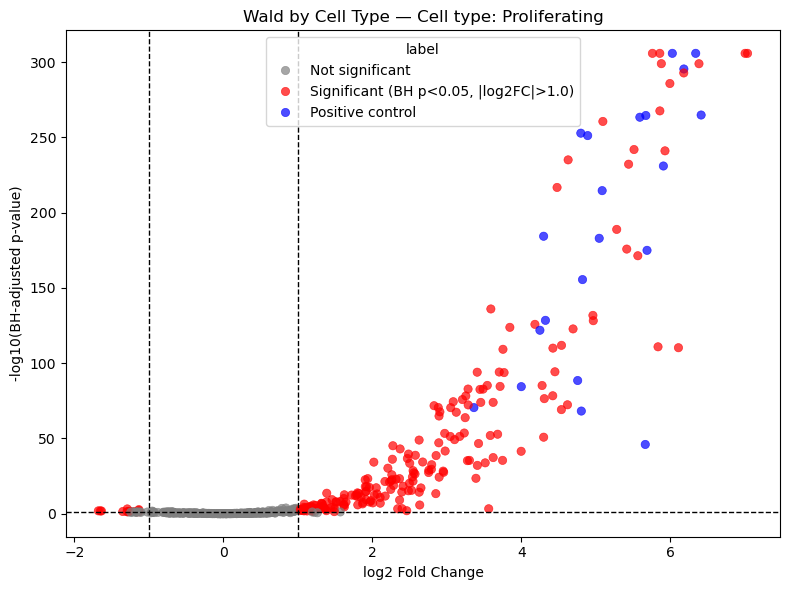

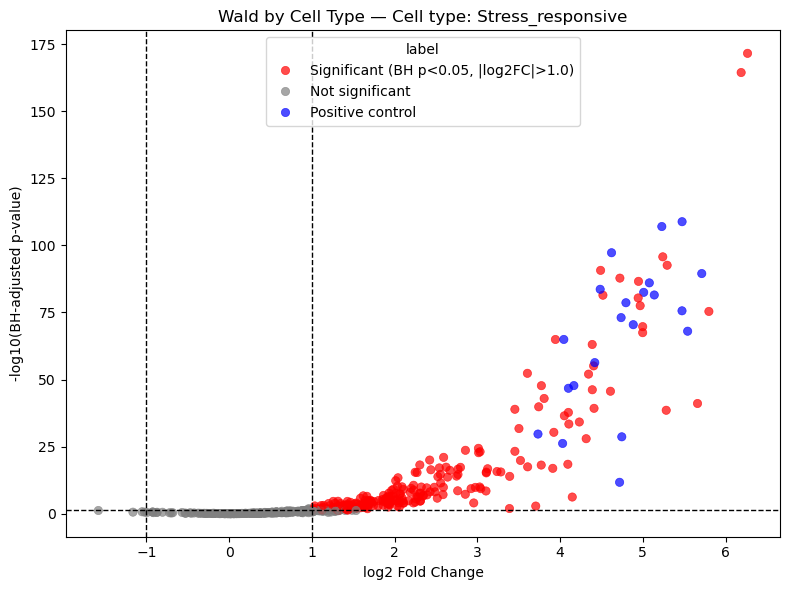

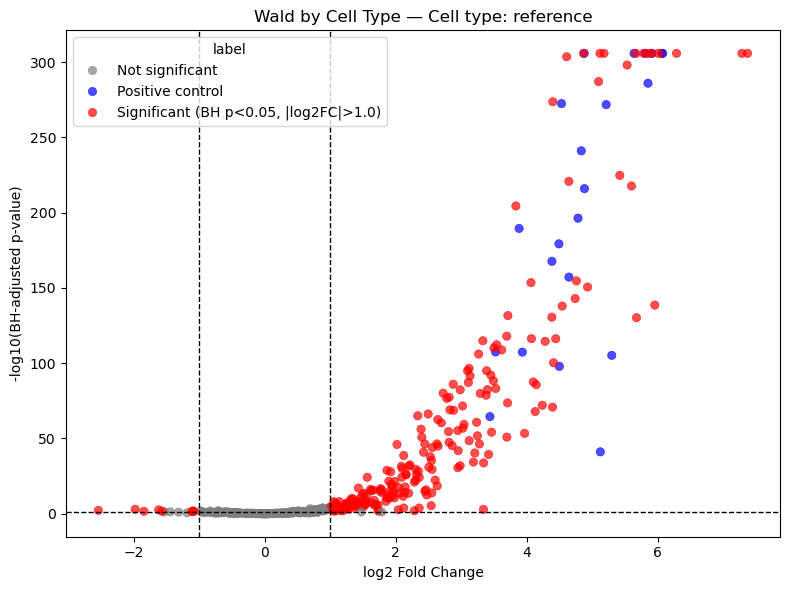

In [10]:
scm.volcano_ctrl_cres(wald_by_ct, title="Wald by Cell Type", pos_ctrl_kw=":pc",   # substring to identify positive controls
    neg_ctrl_kw=":nc",   by_celltype = True,
    average_over_celltypes = False,)

In [12]:
runner = scm.HypothesisTester("mwu", alternative="two-sided")  # can override defaults here
mwu_res_ct = runner.run(hs_all_ct, takeshi, client=client)
mwu_res_ct.to_dataframe()

,comparison_CRE,comparison_cell_type,reference_CRE,reference_cell_type,meta,test_statistic,p_value,fold_change,flattened,ref_mean,comp_mean,test_type,bh_p
0,chr4:2746936:G:A:R:sccelln50stim,Proliferating,reference,Proliferating,cre_activity,125816473.0,1.832468e-01,0.904858,False,0.003795,0.002482,mwu,2.718436e-01
1,chr2:145446458:C:T:A:emVARctl,Proliferating,reference,Proliferating,cre_activity,125300128.5,2.325720e-08,1.582011,False,0.003795,0.011824,mwu,7.317872e-08
2,chr2:203867991:A:G:A:openstringent,Proliferating,reference,Proliferating,cre_activity,125652303.0,8.162175e-01,0.978117,False,0.003795,0.003493,mwu,8.701299e-01
3,chr5:143229960:G:C:A:pritchardsig_openstringent,Proliferating,reference,Proliferating,cre_activity,159619954.5,9.285552e-01,1.020022,False,0.003795,0.004071,mwu,9.529908e-01
4,chr12:54955169:G:T:A:emVARctl,Proliferating,reference,Proliferating,cre_activity,193947165.0,2.145455e-160,3.434531,False,0.003795,0.037379,mwu,2.694546e-159
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1477,chr9:21559962:G:A:A:openstringent,reference,reference,reference,cre_activity,20229905.5,1.846773e-04,1.795951,False,0.003542,0.014321,mwu,4.607606e-04
1478,chr11:1303542:T:C:A:trynkaeQTLopen,reference,reference,reference,cre_activity,10961472.5,3.001605e-03,1.714576,False,0.003542,0.013219,mwu,6.551367e-03
1479,chr2:240624322:G:A:A:trynkaeQTLopen,reference,reference,reference,cre_activity,19026332.5,8.408050e-05,1.596454,False,0.003542,0.011619,mwu,2.155836e-04
1480,chr10:126150324:T:C:R:pc,reference,reference,reference,cre_activity,34809420.5,6.423327e-109,6.373669,False,0.003542,0.076313,mwu,5.987026e-108


In [13]:
mwu_res_ct.to_dataframe().to_csv('%s/takeshi_minp_initial_mwu_test.csv' % path)

,comparison_CRE,comparison_cell_type,reference_CRE,reference_cell_type,meta,test_statistic,p_value,fold_change,flattened,test_type,bh_p
0,chr10:103918153:C:A:A:openstringent,MAX,reference,MAX,bootstrap_activity,0.078712,0.009901,11.249476,False,bootstrap_activity,0.022483
1,chr10:103918153:C:A:R:openstringent,MAX,reference,MAX,bootstrap_activity,0.114341,0.009901,16.487043,False,bootstrap_activity,0.022483
2,chr10:110426390:C:T:A:trynkaeQTLopen_sccelln50...,MAX,reference,MAX,bootstrap_activity,0.017319,0.099010,2.508653,False,bootstrap_activity,0.154610
3,chr10:110426390:C:T:R:trynkaeQTLopen_sccelln50...,MAX,reference,MAX,bootstrap_activity,0.013863,0.198020,1.987975,False,bootstrap_activity,0.266762
4,chr10:126150324:T:C:R:pc,MAX,reference,MAX,bootstrap_activity,0.348930,0.009901,51.055215,False,bootstrap_activity,0.022483
...,...,...,...,...,...,...,...,...,...,...,...
515,chr9:21559962:G:A:A:openstringent,MAX,reference,MAX,bootstrap_activity,0.027042,0.089109,3.925608,False,bootstrap_activity,0.140414
516,chr9:21559962:G:A:R:openstringent,MAX,reference,MAX,bootstrap_activity,0.068627,0.089109,9.868236,False,bootstrap_activity,0.140414
517,chr9:4984530:G:C:A:openstringent_sccelln50stim,MAX,reference,MAX,bootstrap_activity,0.011009,0.079208,1.616325,False,bootstrap_activity,0.127913
518,chr9:4984530:G:C:R:openstringent_sccelln50stim,MAX,reference,MAX,bootstrap_activity,0.028514,0.009901,4.153796,False,bootstrap_activity,0.022483


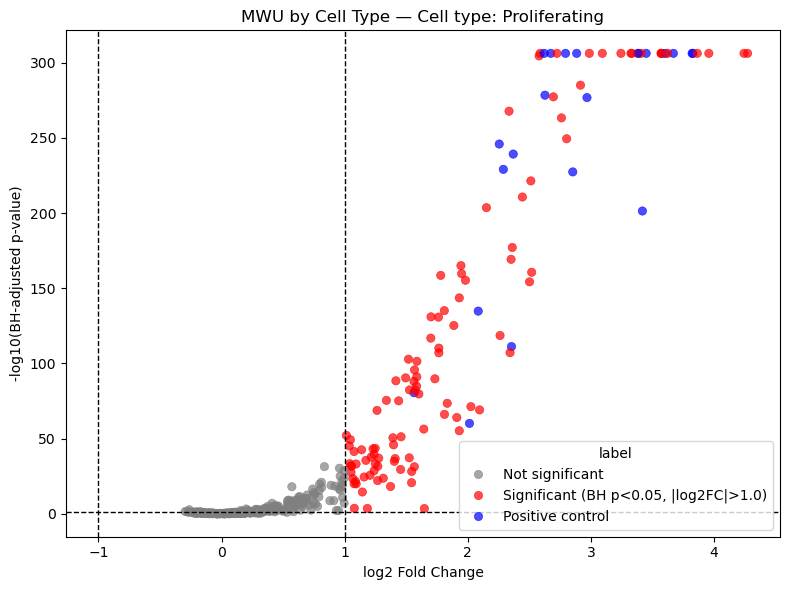

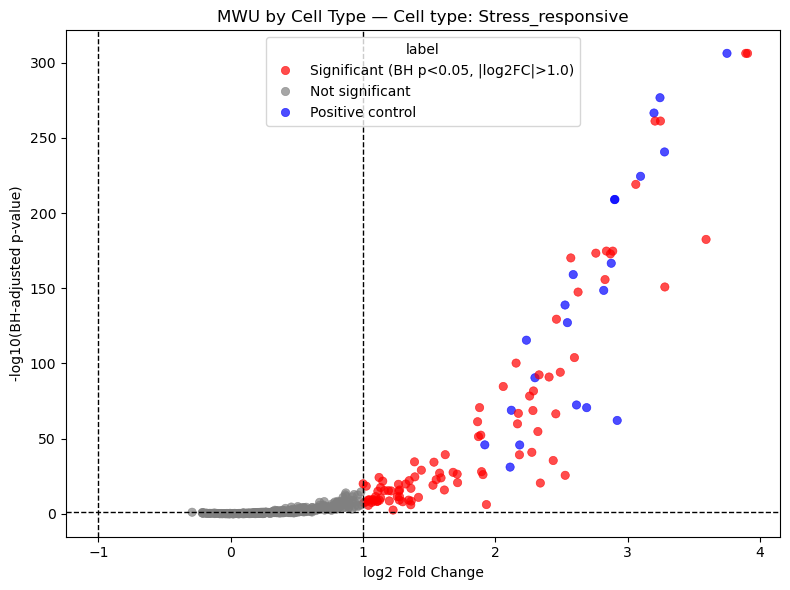

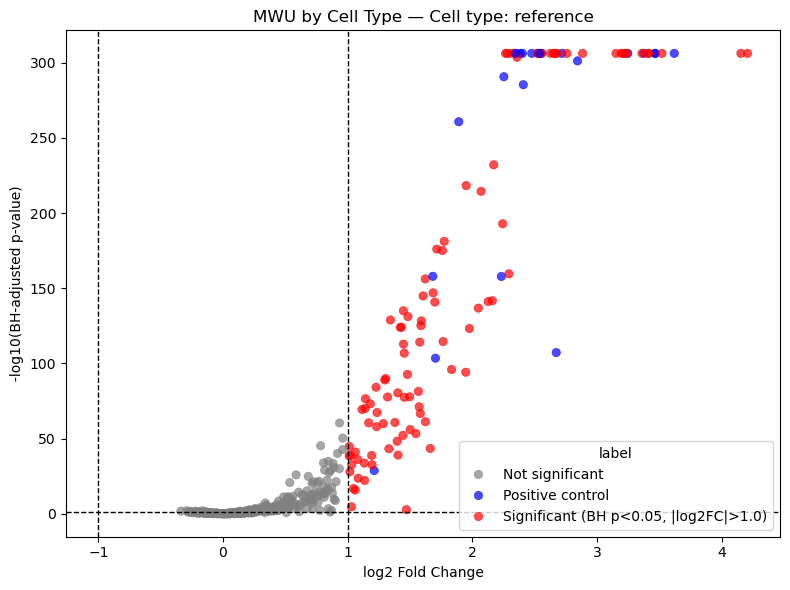

In [14]:

scm.volcano_ctrl_cres(mwu_res_ct, title = 'MWU by Cell Type',pos_ctrl_kw=":pc",   # substring to identify positive controls
    neg_ctrl_kw=":nc",   by_celltype = True,
    average_over_celltypes = False,)

In [ ]:
hs_boot = scm.make_bootstrap_activity_hypotheses(
    counts=takeshi,
    comparison_cres="all",           # or a list of CREs
    controls="reference",            # or ["minP","noP"] if you kept them separate
    meta="bootstrap_activity"
)

runner = scm.HypothesisTester(
    "bootstrap_activity",
    n_bootstraps=100, # default 10K
)
res_boot = runner.run(hs_boot, takeshi, client)
res_boot.to_dataframe()

Pearson r = 0.958 (p = 0.00e+00)
Spearman ρ = 0.994 (p = 0.00e+00)


Text(0, 0.5, 'MWU FC')

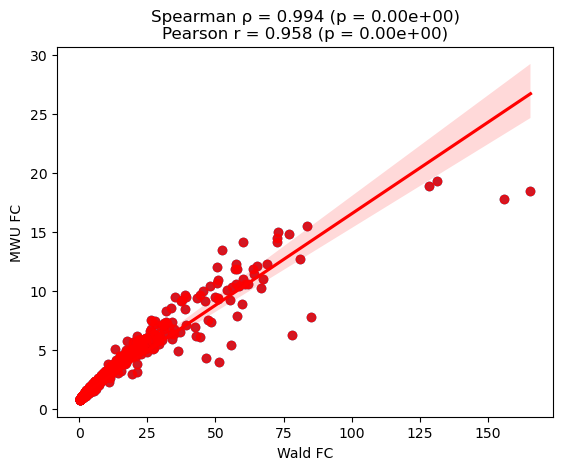

In [16]:
wald_by_ct_df = wald_by_ct.to_dataframe()
mwu_res_ct_df = mwu_res_ct.to_dataframe()

pearson_r, pearson_p = stats.pearsonr(wald_by_ct_df.fold_change,  mwu_res_ct_df.fold_change)
spearman_r, spearman_p = stats.spearmanr(wald_by_ct_df.fold_change,  mwu_res_ct_df.fold_change)
print(f"Pearson r = {pearson_r:.3f} (p = {pearson_p:.2e})")
print(f"Spearman ρ = {spearman_r:.3f} (p = {spearman_p:.2e})")
plt.scatter(x=wald_by_ct_df.fold_change, y = mwu_res_ct_df.fold_change)
sns.regplot(
    x = wald_by_ct_df.fold_change,
    y=mwu_res_ct_df.fold_change,
    scatter=True,
    color='red',
    label=f'Fit: y={pearson_r:.2f}·x'
)
plt.title(f"Spearman ρ = {spearman_r:.3f} (p = {spearman_p:.2e})\nPearson r = {pearson_r:.3f} (p = {pearson_p:.2e})")
plt.xlabel('Wald FC')
plt.ylabel('MWU FC')

Pearson r = 0.846 (p = 0.00e+00)
Spearman ρ = 0.953 (p = 0.00e+00)


Text(0, 0.5, 'MWU bh_p')

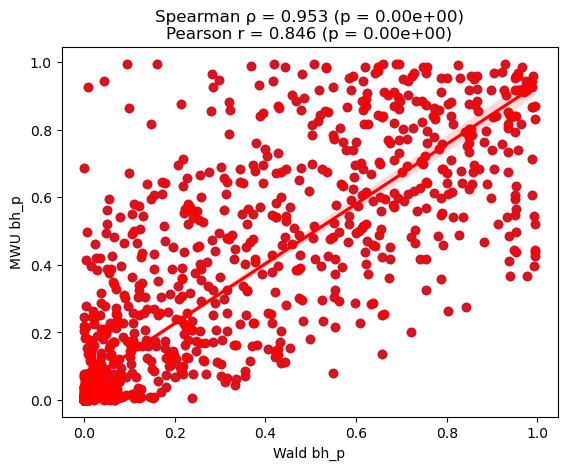

In [17]:
wald_by_ct_df = wald_by_ct.to_dataframe()
mwu_res_ct_df = mwu_res_ct.to_dataframe()

pearson_r, pearson_p = stats.pearsonr(wald_by_ct_df.bh_p,  mwu_res_ct_df.bh_p)
spearman_r, spearman_p = stats.spearmanr(wald_by_ct_df.bh_p,  mwu_res_ct_df.bh_p)
print(f"Pearson r = {pearson_r:.3f} (p = {pearson_p:.2e})")
print(f"Spearman ρ = {spearman_r:.3f} (p = {spearman_p:.2e})")
plt.scatter(x=wald_by_ct_df.bh_p, y = mwu_res_ct_df.bh_p)
sns.regplot(
    x = wald_by_ct_df.bh_p,
    y=mwu_res_ct_df.bh_p,
    scatter=True,
    color='red',
    label=f'Fit: y={pearson_r:.2f}·x'
)
plt.title(f"Spearman ρ = {spearman_r:.3f} (p = {spearman_p:.2e})\nPearson r = {pearson_r:.3f} (p = {pearson_p:.2e})")

plt.xlabel('Wald bh_p')
plt.ylabel('MWU bh_p')

## scp1

In [4]:
import os
if os.path.isdir(path+"/"+name_scp1):
    print("[+] Model found. Loading...")
    primordial=scm.ortho.load(client,path,name_scp1)
    takeshi=primordial.training_data
else:
    print("[+] Model not found. Creating...")

    #load data
    takeshi=scm.scMPRA_data.from_tsv(f"{path}/takeshi_scp1_format_filter.txt")
    neg_controls = list(takeshi.data[takeshi.data.cre_id.str.contains(':nc')].cre_id.unique())
    takeshi.set_negative_controls(neg_controls)
    takeshi.set_reference_cell('IFN')
    takeshi.ortho_filter()

    primordial=scm.ortho()
    primordial.criss_cross(client=client,
                       dat=takeshi)
    primordial.precompute_wald(client)
    primordial.extract_params(client)
    primordial.save(path,name_scp1)


[+] Model not found. Creating...


scMPRAforge: INFO: Dropped 16 of 1584 (cell_type, cre_id) combos with fewer than 3 nonzero entries.


KeyboardInterrupt: 

In [ ]:
# all CREs within each cell type, vs the 'reference' negative control
hs_all_ct = scm.make_all_by_celltype_hypotheses(
    counts=takeshi,
    reference_cre="reference",
    meta="cre_activity",
)

# # all cell types for each CRE, vs the dataset’s baseline cell type
# hs_all_cre = scm.make_all_by_cre_hypotheses(
#     counts=takeshi,
#     reference_cell_type="reference",  # will be normalized to 'reference'
#     meta="cell_specificity",
# )

In [ ]:
hs_all_ct.to_dataframe()

,comparison_CRE,comparison_cell_type,reference_CRE,reference_cell_type,meta
0,chr4:2746936:G:A:R:sccelln50stim,Proliferating,reference,Proliferating,cre_activity
1,chr2:145446458:C:T:A:emVARctl,Proliferating,reference,Proliferating,cre_activity
2,chr2:203867991:A:G:A:openstringent,Proliferating,reference,Proliferating,cre_activity
3,chr5:143229960:G:C:A:pritchardsig_openstringent,Proliferating,reference,Proliferating,cre_activity
4,chr12:54955169:G:T:A:emVARctl,Proliferating,reference,Proliferating,cre_activity
...,...,...,...,...,...
1477,chr9:21559962:G:A:A:openstringent,reference,reference,reference,cre_activity
1478,chr11:1303542:T:C:A:trynkaeQTLopen,reference,reference,reference,cre_activity
1479,chr2:240624322:G:A:A:trynkaeQTLopen,reference,reference,reference,cre_activity
1480,chr10:126150324:T:C:R:pc,reference,reference,reference,cre_activity


In [ ]:
runner = scm.HypothesisTester("wald")
wald_by_ct  = runner.run(hs_all_ct, primordial, client)
wald_by_ct.to_dataframe()

,comparison_CRE,comparison_cell_type,reference_CRE,reference_cell_type,meta,test_statistic,p_value,fold_change,flattened,test_type,bh_p
0,chr4:2746936:G:A:R:sccelln50stim,Proliferating,reference,Proliferating,cre_activity,-2.033253,4.202698e-02,0.593242,False,wald,7.126314e-02
1,chr2:145446458:C:T:A:emVARctl,Proliferating,reference,Proliferating,cre_activity,13.433179,3.864589e-41,5.601790,False,wald,2.328179e-40
2,chr2:203867991:A:G:A:openstringent,Proliferating,reference,Proliferating,cre_activity,-0.524488,5.999395e-01,0.892028,False,wald,6.828804e-01
3,chr5:143229960:G:C:A:pritchardsig_openstringent,Proliferating,reference,Proliferating,cre_activity,0.352872,7.241848e-01,1.066513,False,wald,7.865667e-01
4,chr12:54955169:G:T:A:emVARctl,Proliferating,reference,Proliferating,cre_activity,25.009247,4.849606e-138,12.046757,False,wald,9.456732e-137
...,...,...,...,...,...,...,...,...,...,...,...
1477,chr9:21559962:G:A:A:openstringent,reference,reference,reference,cre_activity,3.242126,1.186415e-03,4.106467,False,wald,2.620368e-03
1478,chr11:1303542:T:C:A:trynkaeQTLopen,reference,reference,reference,cre_activity,2.005976,4.485882e-02,3.447858,False,wald,7.546058e-02
1479,chr2:240624322:G:A:A:trynkaeQTLopen,reference,reference,reference,cre_activity,2.053952,3.998032e-02,2.781118,False,wald,6.826133e-02
1480,chr10:126150324:T:C:R:pc,reference,reference,reference,cre_activity,13.681252,1.314098e-42,34.865397,False,wald,8.080887e-42


In [ ]:
wald_by_ct_df = wald_by_ct.to_dataframe()
wald_by_ct_df[wald_by_ct_df.comparison_CRE.str.contains(":pc")]

,comparison_CRE,comparison_cell_type,reference_CRE,reference_cell_type,meta,test_statistic,p_value,fold_change,flattened,test_type,bh_p
17,chr8:71661108:T:TCACA:R:pc_INS,Proliferating,reference,Proliferating,cre_activity,17.965896,3.604118e-72,10.288868,False,wald,3.123569e-71
37,chr19:54619191:A:G:R:pc,Proliferating,reference,Proliferating,cre_activity,32.607512,3.209534e-233,59.969312,False,wald,9.909437e-232
48,chr19:9434872:C:T:R:pc,Proliferating,reference,Proliferating,cre_activity,34.901718,7.001510e-267,50.933787,False,wald,2.730589e-265
69,chr1:110198727:C:G:R:pc,Proliferating,reference,Proliferating,cre_activity,29.013794,4.407833e-185,33.013042,False,wald,1.088735e-183
73,chr4:68567025:T:G:R:pc,Proliferating,reference,Proliferating,cre_activity,19.676810,3.407882e-86,15.989669,False,wald,3.769016e-85
...,...,...,...,...,...,...,...,...,...,...,...
1263,chr5:175815782:G:C:R:pc,reference,reference,reference,cre_activity,35.423859,7.330551e-275,23.110679,False,wald,3.195258e-273
1281,chr19:3762698:C:T:R:pc,reference,reference,reference,cre_activity,39.690171,2.225074e-308,49.808765,False,wald,1.433722e-306
1391,chr6:29910276:T:G:R:pc,reference,reference,reference,cre_activity,28.719829,2.157692e-181,22.491758,False,wald,5.242131e-180
1456,chr17:43807063:C:T:R:pc,reference,reference,reference,cre_activity,33.312433,2.550955e-243,28.497771,False,wald,8.401144e-242


In [ ]:
wald_by_ct_df.to_csv('%s/takeshi_minp_initial_wald_modeling.csv' % path)

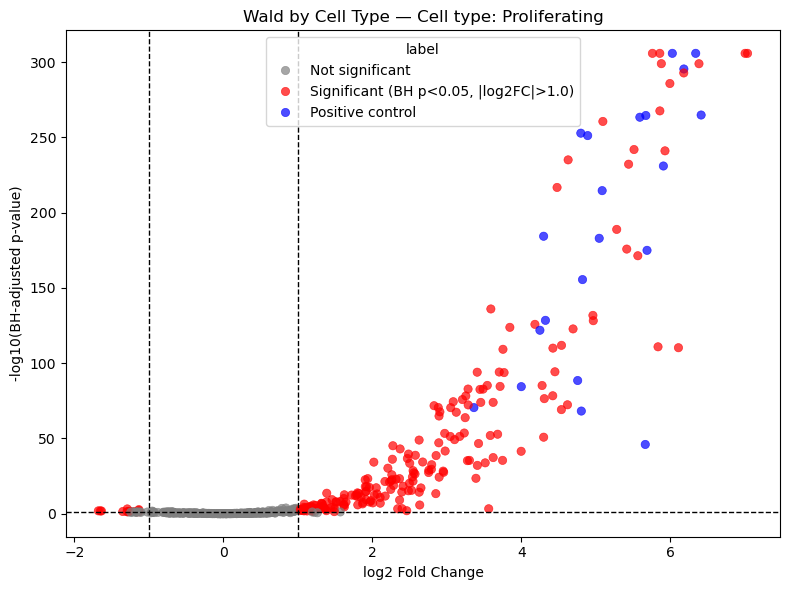

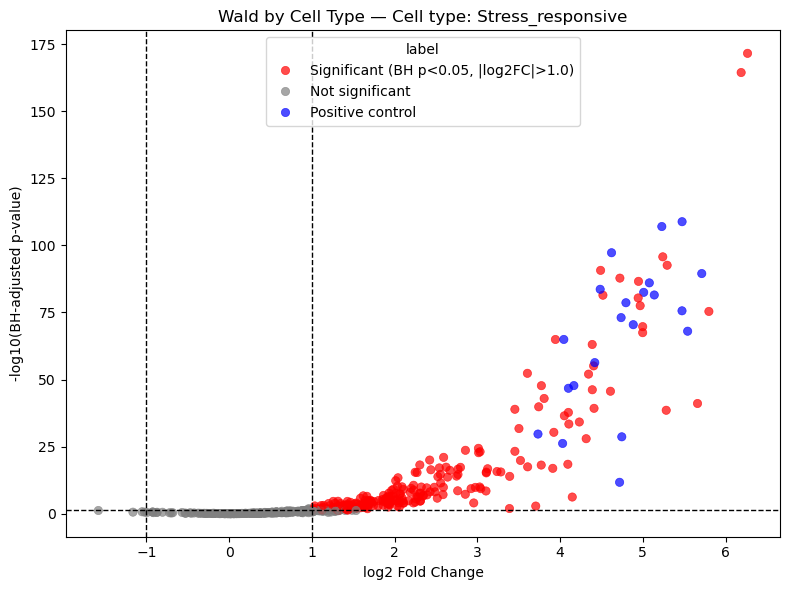

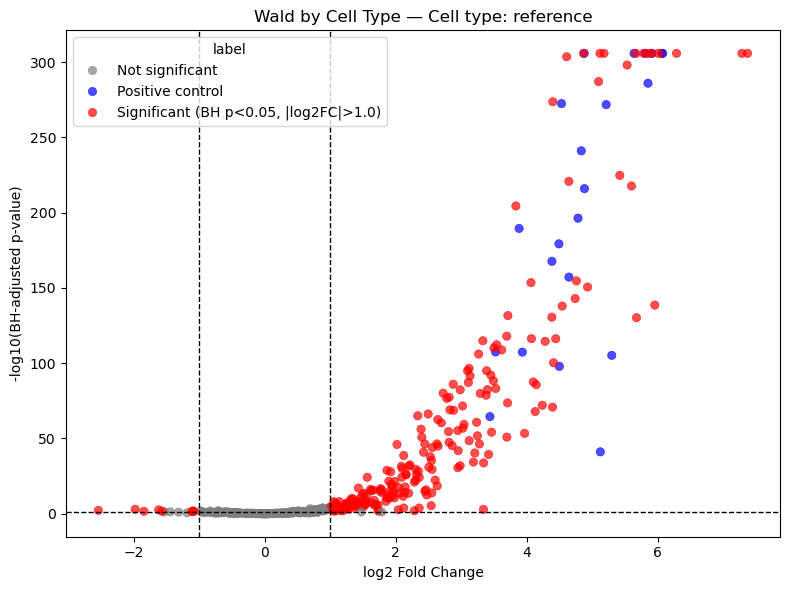

In [ ]:
scm.volcano_ctrl_cres(wald_by_ct, title="Wald by Cell Type", pos_ctrl_kw=":pc",   # substring to identify positive controls
    neg_ctrl_kw=":nc",   by_celltype = True,
    average_over_celltypes = False,)

In [ ]:
runner = scm.HypothesisTester("mwu", alternative="two-sided")  # can override defaults here
mwu_res_ct = runner.run(hs_all_ct, takeshi, client=client)
mwu_res_ct.to_dataframe()

,comparison_CRE,comparison_cell_type,reference_CRE,reference_cell_type,meta,test_statistic,p_value,fold_change,flattened,ref_mean,comp_mean,test_type,bh_p
0,chr4:2746936:G:A:R:sccelln50stim,Proliferating,reference,Proliferating,cre_activity,125816473.0,1.832468e-01,0.904858,False,0.003795,0.002482,mwu,2.718436e-01
1,chr2:145446458:C:T:A:emVARctl,Proliferating,reference,Proliferating,cre_activity,125300128.5,2.325720e-08,1.582011,False,0.003795,0.011824,mwu,7.317872e-08
2,chr2:203867991:A:G:A:openstringent,Proliferating,reference,Proliferating,cre_activity,125652303.0,8.162175e-01,0.978117,False,0.003795,0.003493,mwu,8.701299e-01
3,chr5:143229960:G:C:A:pritchardsig_openstringent,Proliferating,reference,Proliferating,cre_activity,159619954.5,9.285552e-01,1.020022,False,0.003795,0.004071,mwu,9.529908e-01
4,chr12:54955169:G:T:A:emVARctl,Proliferating,reference,Proliferating,cre_activity,193947165.0,2.145455e-160,3.434531,False,0.003795,0.037379,mwu,2.694546e-159
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1477,chr9:21559962:G:A:A:openstringent,reference,reference,reference,cre_activity,20229905.5,1.846773e-04,1.795951,False,0.003542,0.014321,mwu,4.607606e-04
1478,chr11:1303542:T:C:A:trynkaeQTLopen,reference,reference,reference,cre_activity,10961472.5,3.001605e-03,1.714576,False,0.003542,0.013219,mwu,6.551367e-03
1479,chr2:240624322:G:A:A:trynkaeQTLopen,reference,reference,reference,cre_activity,19026332.5,8.408050e-05,1.596454,False,0.003542,0.011619,mwu,2.155836e-04
1480,chr10:126150324:T:C:R:pc,reference,reference,reference,cre_activity,34809420.5,6.423327e-109,6.373669,False,0.003542,0.076313,mwu,5.987026e-108


In [ ]:
mwu_res_ct.to_dataframe().to_csv('%s/takeshi_minp_initial_mwu_test.csv' % path)

,comparison_CRE,comparison_cell_type,reference_CRE,reference_cell_type,meta,test_statistic,p_value,fold_change,flattened,test_type,bh_p
0,chr10:103918153:C:A:A:openstringent,MAX,reference,MAX,bootstrap_activity,0.078712,0.009901,11.249476,False,bootstrap_activity,0.022483
1,chr10:103918153:C:A:R:openstringent,MAX,reference,MAX,bootstrap_activity,0.114341,0.009901,16.487043,False,bootstrap_activity,0.022483
2,chr10:110426390:C:T:A:trynkaeQTLopen_sccelln50...,MAX,reference,MAX,bootstrap_activity,0.017319,0.099010,2.508653,False,bootstrap_activity,0.154610
3,chr10:110426390:C:T:R:trynkaeQTLopen_sccelln50...,MAX,reference,MAX,bootstrap_activity,0.013863,0.198020,1.987975,False,bootstrap_activity,0.266762
4,chr10:126150324:T:C:R:pc,MAX,reference,MAX,bootstrap_activity,0.348930,0.009901,51.055215,False,bootstrap_activity,0.022483
...,...,...,...,...,...,...,...,...,...,...,...
515,chr9:21559962:G:A:A:openstringent,MAX,reference,MAX,bootstrap_activity,0.027042,0.089109,3.925608,False,bootstrap_activity,0.140414
516,chr9:21559962:G:A:R:openstringent,MAX,reference,MAX,bootstrap_activity,0.068627,0.089109,9.868236,False,bootstrap_activity,0.140414
517,chr9:4984530:G:C:A:openstringent_sccelln50stim,MAX,reference,MAX,bootstrap_activity,0.011009,0.079208,1.616325,False,bootstrap_activity,0.127913
518,chr9:4984530:G:C:R:openstringent_sccelln50stim,MAX,reference,MAX,bootstrap_activity,0.028514,0.009901,4.153796,False,bootstrap_activity,0.022483


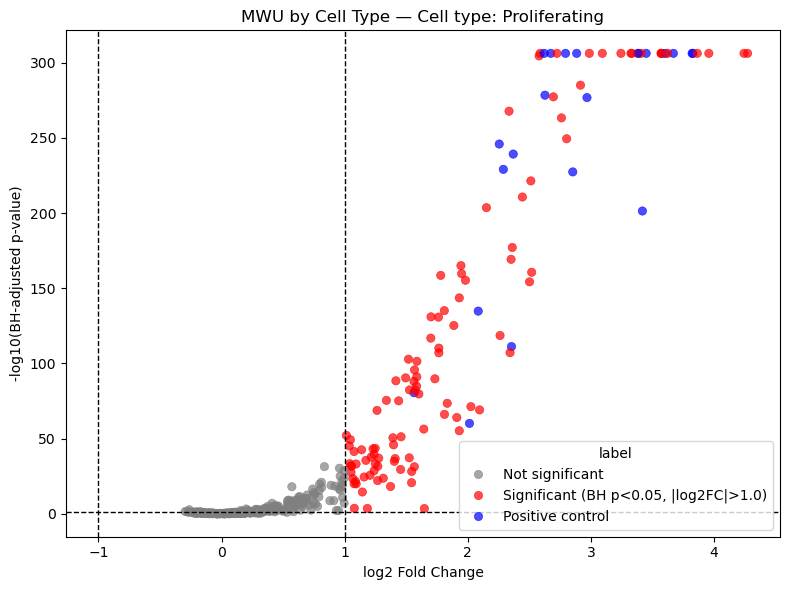

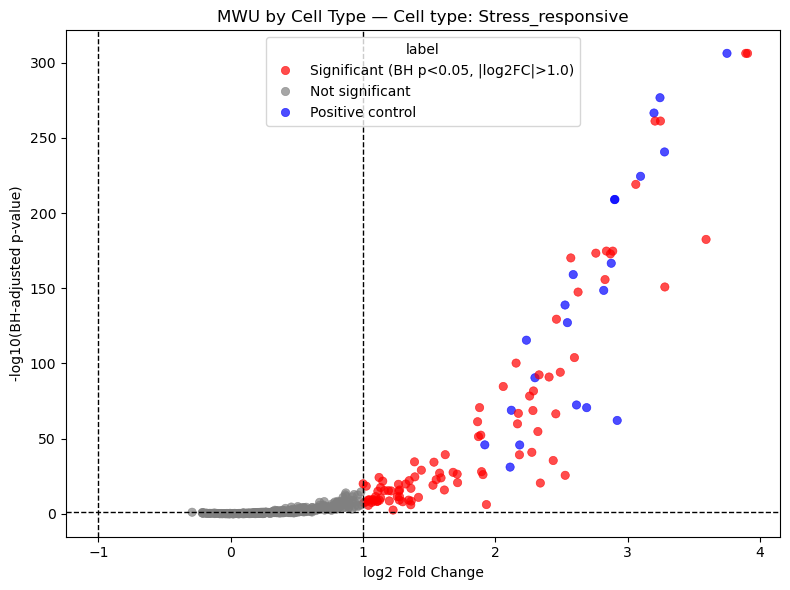

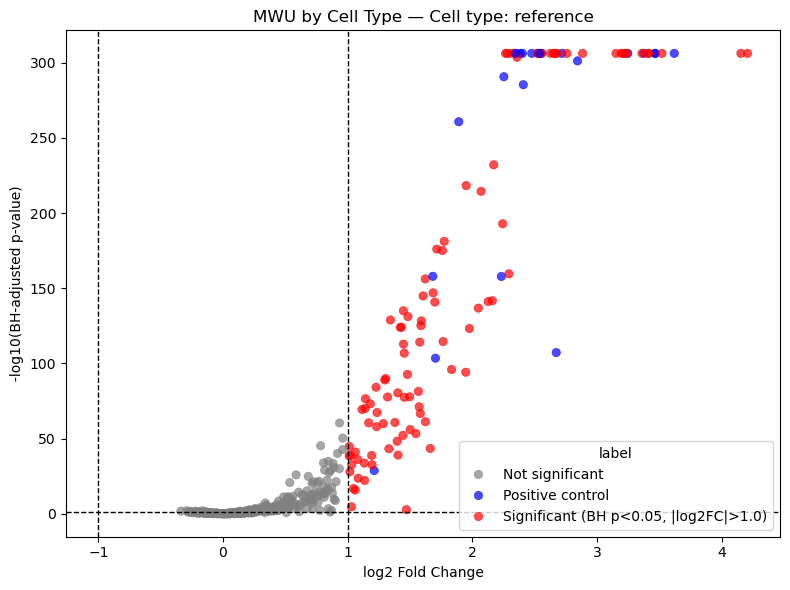

In [ ]:

scm.volcano_ctrl_cres(mwu_res_ct, title = 'MWU by Cell Type',pos_ctrl_kw=":pc",   # substring to identify positive controls
    neg_ctrl_kw=":nc",   by_celltype = True,
    average_over_celltypes = False,)

In [ ]:
hs_boot = scm.make_bootstrap_activity_hypotheses(
    counts=takeshi,
    comparison_cres="all",           # or a list of CREs
    controls="reference",            # or ["minP","noP"] if you kept them separate
    meta="bootstrap_activity"
)

runner = scm.HypothesisTester(
    "bootstrap_activity",
    n_bootstraps=100, # default 10K
)
res_boot = runner.run(hs_boot, takeshi, client)
res_boot.to_dataframe()

Pearson r = 0.958 (p = 0.00e+00)
Spearman ρ = 0.994 (p = 0.00e+00)


Text(0, 0.5, 'MWU FC')

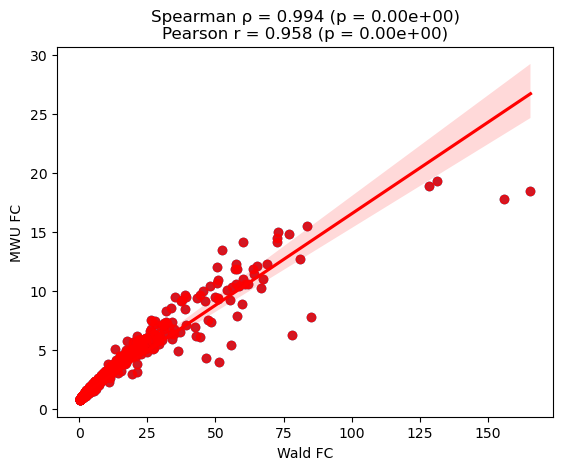

In [ ]:
wald_by_ct_df = wald_by_ct.to_dataframe()
mwu_res_ct_df = mwu_res_ct.to_dataframe()

pearson_r, pearson_p = stats.pearsonr(wald_by_ct_df.fold_change,  mwu_res_ct_df.fold_change)
spearman_r, spearman_p = stats.spearmanr(wald_by_ct_df.fold_change,  mwu_res_ct_df.fold_change)
print(f"Pearson r = {pearson_r:.3f} (p = {pearson_p:.2e})")
print(f"Spearman ρ = {spearman_r:.3f} (p = {spearman_p:.2e})")
plt.scatter(x=wald_by_ct_df.fold_change, y = mwu_res_ct_df.fold_change)
sns.regplot(
    x = wald_by_ct_df.fold_change,
    y=mwu_res_ct_df.fold_change,
    scatter=True,
    color='red',
    label=f'Fit: y={pearson_r:.2f}·x'
)
plt.title(f"Spearman ρ = {spearman_r:.3f} (p = {spearman_p:.2e})\nPearson r = {pearson_r:.3f} (p = {pearson_p:.2e})")
plt.xlabel('Wald FC')
plt.ylabel('MWU FC')

Pearson r = 0.846 (p = 0.00e+00)
Spearman ρ = 0.953 (p = 0.00e+00)


Text(0, 0.5, 'MWU bh_p')

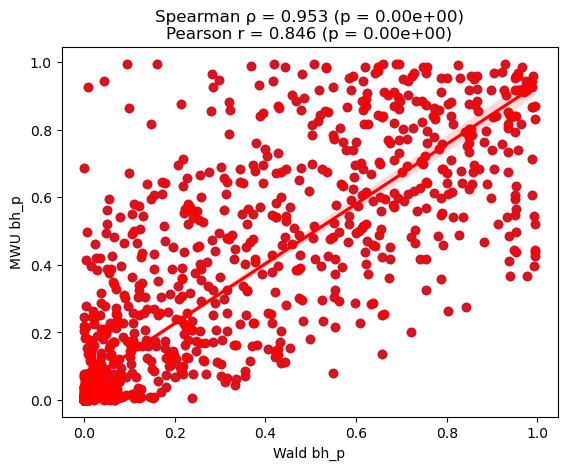

In [ ]:
wald_by_ct_df = wald_by_ct.to_dataframe()
mwu_res_ct_df = mwu_res_ct.to_dataframe()

pearson_r, pearson_p = stats.pearsonr(wald_by_ct_df.bh_p,  mwu_res_ct_df.bh_p)
spearman_r, spearman_p = stats.spearmanr(wald_by_ct_df.bh_p,  mwu_res_ct_df.bh_p)
print(f"Pearson r = {pearson_r:.3f} (p = {pearson_p:.2e})")
print(f"Spearman ρ = {spearman_r:.3f} (p = {spearman_p:.2e})")
plt.scatter(x=wald_by_ct_df.bh_p, y = mwu_res_ct_df.bh_p)
sns.regplot(
    x = wald_by_ct_df.bh_p,
    y=mwu_res_ct_df.bh_p,
    scatter=True,
    color='red',
    label=f'Fit: y={pearson_r:.2f}·x'
)
plt.title(f"Spearman ρ = {spearman_r:.3f} (p = {spearman_p:.2e})\nPearson r = {pearson_r:.3f} (p = {pearson_p:.2e})")

plt.xlabel('Wald bh_p')
plt.ylabel('MWU bh_p')

In [7]:
cluster.close()